# Cluster Effects Preprocessing

In [2]:
import os
import datasets
import pandas as pd
import numpy as np
import lightning.pytorch as pl

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm

from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import textwrap
from IPython.display import display  # Import display function

import doubleml as dml
from doubleml.utils import DMLDummyRegressor

from sklearn.cluster import KMeans
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, pairwise_distances
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from lightgbm import LGBMRegressor
from utils.utils_data2 import (
    load_pred_and_emb,
    center_and_norm,
    get_pca,
    get_cluster,
    get_similarities,
    add_lags_and_scale_data,
)

confidence_level = 0.9
ci_level_name = f"{round((confidence_level) * 100, 1)}%"
ci_names = [
    f"{round((1 - confidence_level) * 100 / 2, 1)}%",
    f"{round((1 + confidence_level) * 100 / 2, 1)}%",
]
print(ci_level_name)
print(ci_names)

90.0%
['5.0%', '95.0%']


## Set Output Directory

In [4]:
output_dir = "../../output/A4_replication_clothes_data/01_output_cluster"
Path(output_dir).mkdir(parents=True, exist_ok=True)


## Data Loading and Preprocessing

In [6]:
txt_only = False
include_embeddings = True
dataframe_name = f"dataset_txt_only_{txt_only}_embeddings_{include_embeddings}"
df_full_train = pd.read_csv(f"../../data/A4_replication_clothes_data/{dataframe_name}_train.zip")
df_full_val = pd.read_csv(f"../../data/A4_replication_clothes_data/{dataframe_name}_val.zip")

columns_to_drop = []

df_full_train = df_full_train.drop(columns=columns_to_drop)
df_full_val = df_full_val.drop(columns=columns_to_drop)

df_full_train = df_full_train.dropna()
df_full_val = df_full_val.dropna()

dummy_subcat_names = [
    category for category in df_full_val["subcat_aggregated"].unique()
]
all_time_steps = sorted([str(date) for date in df_full_val["date"].unique()])

print(f"Dummy subcat names: {dummy_subcat_names}")
print(f"All time steps: {all_time_steps}")
df_full_val.columns

Dummy subcat names: ['Residual', 'T-Shirts', 'Casual', 'Active Shorts', 'Sunglasses', 'Tunics', 'Fashion Sneakers', 'Everyday Bras', 'Cardigans', 'Sports Bras', 'Tanks & Camis', 'Pullovers', 'Briefs', 'Button-Down Shirts', 'Cover-Ups', 'Women, Skirts', 'Slippers', 'Leggings', 'Sets', 'Jeans', 'Blouses & Button-Down Shirts']
All time steps: ['2023-03-27', '2023-04-24', '2023-05-22', '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11', '2023-10-09', '2023-11-06', '2023-12-04', '2024-01-01', '2024-01-29', '2024-02-26', '2024-03-25']


Index(['ASIN', 'date', 'index', 'Q_t', 'P_bb_t', 'text', 'window',
       'REVIEW_COUNT', 'RATING', 'Anzahl Neu Angebote: Aktuell',
       ...
       'Q_t-2', 'P_bb_t-2', 'REVIEW_COUNT_t-2', 'RATING_t-2', 'Delta_Q_t',
       'Delta_P_bb_t', 'pred_ml_l', 'pred_ml_m', 'pred_ml_l_lag_1',
       'pred_ml_m_lag_1'],
      dtype='object', length=353)

In [7]:
df_full_train = df_full_train.set_index(["ASIN", "date"])
df_full_val = df_full_val.set_index(["ASIN", "date"])

In [8]:
columns = [
    "ASIN",
    "Q_t",
    "P_bb_t",
    "text",
    "date",
    "window",
    "REVIEW_COUNT",
    "RATING",
    "Anzahl Neu Angebote: Aktuell",
    "Anzahl der abgerufenen Live-Angebote: Neu, FBA",
    "Anzahl der abgerufenen Live-Angebote: Neu, FBM",
    #'Blitzangebot: Aktuell',
    "Blitzangebot: Ist Tiefstpreissubcat_aggregated",
]

# Clustering

In [9]:
emb_columns = ["ASIN", "date"] + [f"emb_{i}" for i in range(256)]
emb_columns_txt = ["ASIN", "date"] + [f"emb_{i}_txt" for i in range(256)]

In [10]:
full_embeddings_txtimg = center_and_norm(
    df_full_train.reset_index()[emb_columns], df_full_val.reset_index()[emb_columns]
)

full_embeddings_txtimg.shape

(24932, 256)

In [11]:
kmeans_txtimg_labels, cluster_centroids_txtimg = get_cluster(
    full_embeddings_txtimg, n_clusters=5
)

## PCA Visualization

In [12]:
pca_img = PCA(n_components=2, random_state=42)
pca_img_results = pca_img.fit_transform(full_embeddings_txtimg)

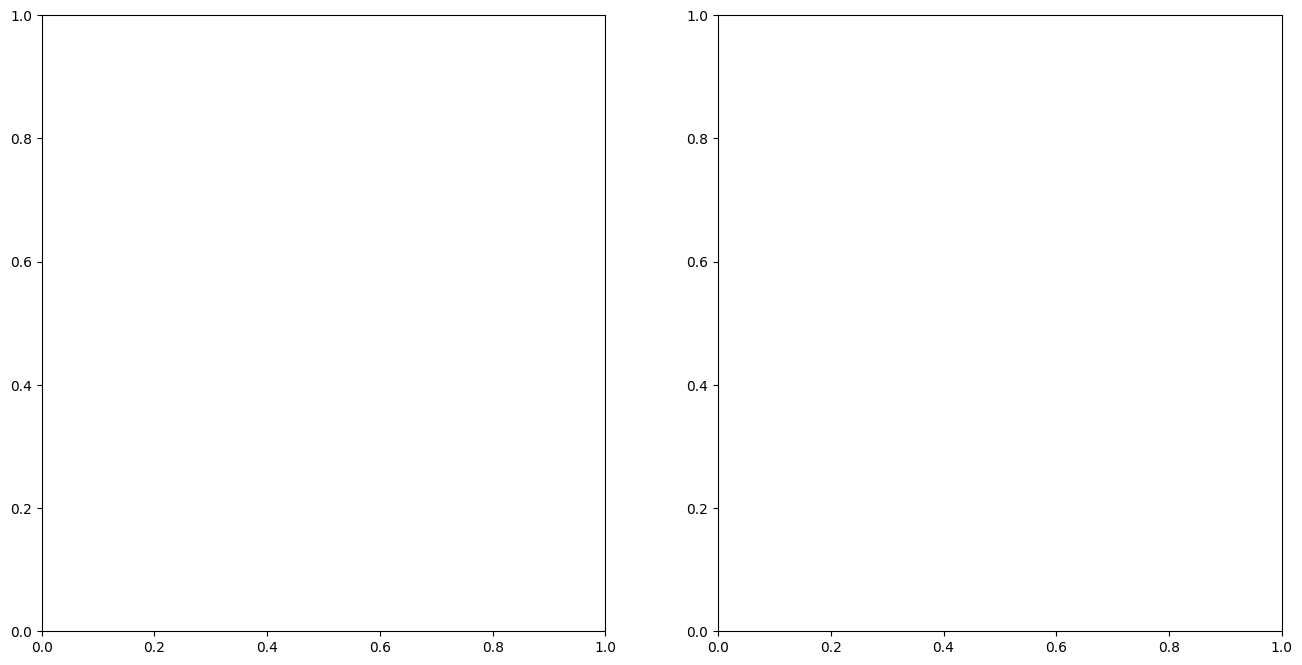

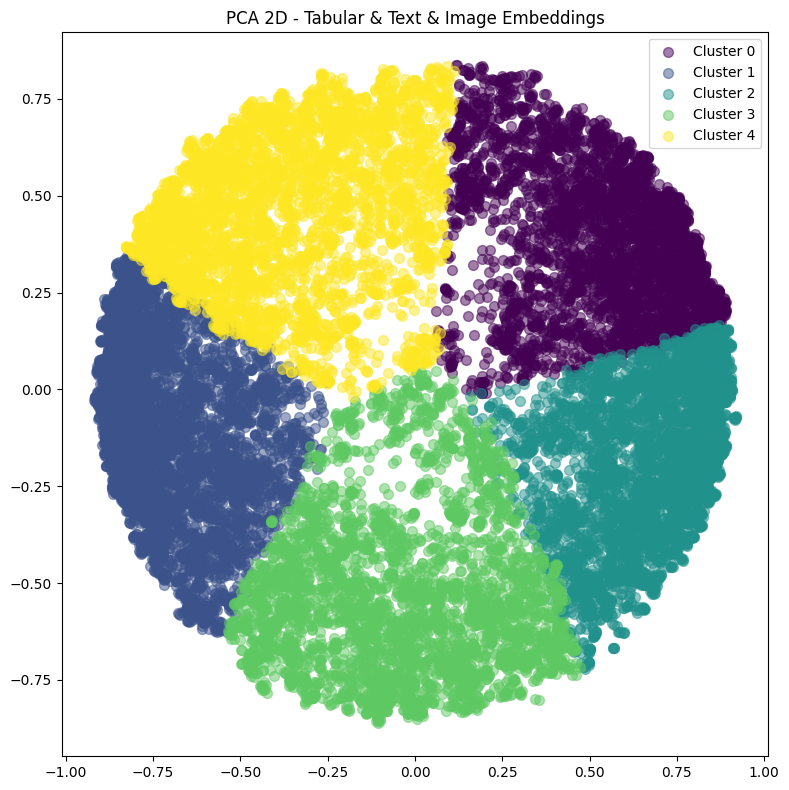

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
unique_cluster_ids = np.unique(kmeans_txtimg_labels)
# Plot for text embeddings
colors = cm.viridis(np.linspace(0, 1, len(unique_cluster_ids)))

fig, axes = plt.subplots(1, 1, figsize=(8, 8))


# Plot for image embeddings
unique_cluster_ids = np.unique(kmeans_txtimg_labels)

for i, cluster_id in enumerate(unique_cluster_ids):
    axes.scatter(
        pca_img_results[kmeans_txtimg_labels == cluster_id, 0],
        pca_img_results[kmeans_txtimg_labels == cluster_id, 1],
        color=colors[i],
        label=f"Cluster {cluster_id}",
        s=50,
        alpha=0.5,
    )
axes.set_title("PCA 2D - Tabular & Text & Image Embeddings")
axes.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "pca_2d_clusters.png"))
plt.show()

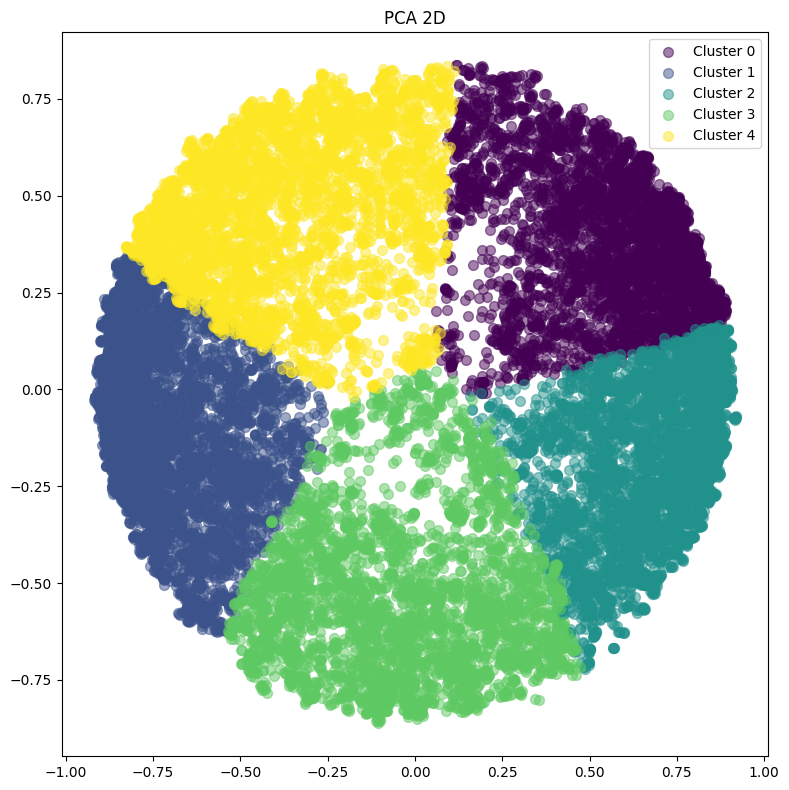

In [14]:
fig = plt.figure(figsize=(8, 8))
unique_cluster_ids = np.unique(kmeans_txtimg_labels)
colors = cm.viridis(np.linspace(0, 1, len(unique_cluster_ids)))

for i, cluster_id in enumerate(unique_cluster_ids):
    plt.scatter(
        pca_img_results[kmeans_txtimg_labels == cluster_id, 0],
        pca_img_results[kmeans_txtimg_labels == cluster_id, 1],
        color=colors[i],
        label=f"Cluster {cluster_id}",
        s=50,
        alpha=0.5,
    )
plt.title("PCA 2D")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "pca_img_clusters.png"))
plt.show()

## 3D PCA Visualization

In [15]:
pca_img_3d = PCA(n_components=3, random_state=42)
pca_img_3d_results = pca_img_3d.fit_transform(full_embeddings_txtimg)

In [16]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import matplotlib.colors as mcolors  # To convert colors to hex

colors = [
    mcolors.rgb2hex(cm.viridis(i)) for i in np.linspace(0, 1, len(unique_cluster_ids))
]

fig = make_subplots(rows=1, cols=1, specs=[[{"type": "scatter3d"}]])


# Convert index to row and column in a 2x2 grid
row, col = divmod(0, 1)

# Create traces for each cluster
for i, cluster_id in enumerate(unique_cluster_ids):
    mask = kmeans_txtimg_labels == cluster_id
    fig.add_trace(
        go.Scatter3d(
            x=pca_img_3d_results[mask, 0],  # PC1
            y=pca_img_3d_results[mask, 1],  # PC2
            z=pca_img_3d_results[mask, 2],  # PC3
            mode="markers",
            marker=dict(size=5, color=colors[i], opacity=0.3),
            name=f"Cluster {cluster_id}",
        ),
        row=row + 1,
        col=col + 1,
    )

# Step 5: Set titles and layout
fig.update_layout(
    height=800,
    width=800,
    template="none",
    margin=dict(t=5, r=20, b=10, l=20),
    scene=dict(
        xaxis=dict(range=[-1, 1]),
        yaxis=dict(range=[-1, 1]),
        zaxis=dict(range=[-1, 1]),
        camera_eye=dict(x=1, y=2, z=1),
    ),
)

fig.update_layout(
    legend=dict(
        x=0.5,  # Center the legend horizontally
        y=-0.01,  # Place the legend below the plot
        xanchor="center",  # Align legend horizontally by its center
        yanchor="top",  # Align legend vertically by its top
        orientation="h",  # Arrange legend items horizontally
        bgcolor="rgba(255, 255, 255, 0.7)",  # Optional: Add a semi-transparent background
        bordercolor="black",  # Optional: Add a border
        borderwidth=1,  # Optional: Set border width
    )
)

# Step 6: Show plot
fig.show()

c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




Group 1 und 3

sowie 0, 2, 4

In [17]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import matplotlib.colors as mcolors  # To convert colors to hex

# Assuming pca_img_3d_results and pca_txt_3d_results are already computed
unique_cluster_ids_img = np.unique(kmeans_txtimg_labels)

colors_img = [
    mcolors.rgb2hex(cm.viridis(i))
    for i in np.linspace(0, 1, len(unique_cluster_ids_img))
]

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "scatter3d"}, {"type": "scatter3d"}]],
    subplot_titles=(
        "Tabular & Text Embeddings",
        "Tabular & Text & Image Embeddings",
    ),  # Add subplot titles
)

# Create traces for each cluster for image embeddings
for i, cluster_id in enumerate(unique_cluster_ids_img):
    mask = kmeans_txtimg_labels == cluster_id
    fig.add_trace(
        go.Scatter3d(
            x=pca_img_3d_results[mask, 0],  # PC1
            y=pca_img_3d_results[mask, 1],  # PC2
            z=pca_img_3d_results[mask, 2],  # PC3
            mode="markers",
            marker=dict(size=5, color=colors_img[i], opacity=0.3),
            name=f"Cluster {cluster_id}",
            showlegend=False,  # Hide legend for the second subplot
        ),
        row=1,
        col=2,
    )

# Set titles and layout with camera angles
fig.update_layout(
    height=600,
    width=900,  # Adjusted figure size
    title_text="PCA 3D Cluster Visualization",
    scene_camera=dict(
        eye=dict(
            x=1.25, y=1.25, z=1.25
        )  # Adjust the camera angle for the first subplot
    ),
    scene2_camera=dict(
        eye=dict(
            x=1.25, y=1.25, z=1.25
        )  # Adjust the camera angle for the second subplot
    ),
)

# Show plot
fig.show()

In [18]:
df_full = pd.concat([df_full_train, df_full_val]).reset_index()

In [19]:
df_full

,ASIN,date,index,Q_t,P_bb_t,text,window,REVIEW_COUNT,RATING,Anzahl Neu Angebote: Aktuell,...,Q_t-2,P_bb_t-2,REVIEW_COUNT_t-2,RATING_t-2,Delta_Q_t,Delta_P_bb_t,pred_ml_l,pred_ml_m,pred_ml_l_lag_1,pred_ml_m_lag_1
0,B0006I47DW,2023-03-27,84966,-7.061855,2.267846,Vanity Fair Women's Perfectly Yours Ravissant ...,28.0,12302.428571,4.300000,5.0,...,-7.055066,2.209804,11998.428571,4.300000,0.045805,0.060749,-7.195308,2.088980,-7.493722,2.080551
1,B007HQIAL6,2023-03-27,84968,-8.833968,3.273716,NIKE Unisex Performance Cushion Quarter Socks ...,28.0,1379.000000,4.600000,21.0,...,-8.481958,3.351632,1317.392857,4.600000,0.052624,-0.005677,-9.032726,3.447598,-8.758355,3.351776
2,B00J5Q0N0W,2023-03-27,84969,-6.943708,1.822935,BIRCH's Oval Shoelaces 27 Colors Half Round 1/...,28.0,11961.642857,4.500000,1.0,...,-7.204919,1.822935,11708.821429,4.500000,0.110618,0.000000,-7.610892,1.912282,-7.814979,1.881807
3,B076GT47DW,2023-03-27,84974,-6.645277,2.753570,Warner's Women's Blissful Benefits Ultrasoft W...,28.0,17731.321429,4.500000,3.0,...,-6.760663,2.756636,17187.000000,4.500000,-0.051743,0.037835,-6.984411,2.628364,-6.531809,2.467175
4,B0788DWB2H,2023-03-27,84975,-2.445448,2.638343,Leggings Depot Women's Relaxed fit Jogger Pant...,28.0,100618.142857,4.400000,1.0,...,-3.074675,2.638343,97444.321429,4.400000,-0.232475,0.000000,-4.774313,2.679661,-4.671988,2.633964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24927,B0CFFH4F1W,2024-03-25,607775,-8.593135,4.827914,Orthofeet Women's Orthopedic All Black Knit Ki...,28.0,149.142857,4.300000,2.0,...,-13.392769,4.904904,84.857143,4.200000,0.990799,-0.028182,-9.553353,3.841740,-9.508858,3.664651
24928,B0CGHX9HS4,2024-03-25,607776,-12.607326,3.366951,Colorful House Unisex's Ugly Christmas Jumper ...,28.0,832.250000,3.900000,1.0,...,-11.546156,3.366951,762.500000,3.900000,-0.273226,0.000000,-12.575933,3.453804,-12.014111,3.453804
24929,B0CHY1XBQ6,2024-03-25,607777,-10.156162,3.619242,SHEWIN Womens Oversized Sweatshirt Hoodies Cas...,28.0,70.357143,4.207143,1.0,...,-10.165481,3.604622,46.285714,4.285714,-0.460378,-0.034861,-9.798240,3.679737,-9.788281,3.708409
24930,B0CMDC248G,2024-03-25,607780,-12.617679,2.301585,"Dielianyi Crop Band for T-Shirts,Tuck Band, Sw...",28.0,2.000000,3.000000,1.0,...,-13.917004,2.301585,1.000000,5.000000,-0.695675,0.000000,-9.359831,2.721486,-9.417440,2.623288


In [20]:
n_clusters = 5

centroids_img = cluster_centroids_txtimg
cl_img = [f"similarity_cluster_img_{i}" for i in range(n_clusters)]

In [21]:
from sklearn.metrics import pairwise_distances

for i_embedding, embedding in enumerate(full_embeddings_txtimg.values):
    for i, centroid in enumerate(centroids_img):
        similarity = 1.0 - pairwise_distances(
            embedding.reshape(1, -1), centroid.reshape(1, -1), metric="cosine"
        )
        df_full.loc[i_embedding, cl_img[i]] = similarity

In [22]:
n_neighbors = 4
closest_points_img = [None]
closest_points_indices_val_img = None
for embeddings, centroids, val_cluster_ids in zip(
    [full_embeddings_txtimg], [centroids_img], [kmeans_txtimg_labels]
):
    for i_embedding, embedding in enumerate([embeddings]):
        distances = pairwise_distances(embedding, centroids, metric="euclidean")
        closest_points_indices = []
        for i in range(n_clusters):
            cluster_indices = np.where(val_cluster_ids == i)[0]
            cluster_distances = distances[cluster_indices, i]
            sorted_indices = cluster_indices[np.argsort(cluster_distances)]

            closest_indices_i = []
            seen_asins = set()

            for idx in sorted_indices:
                asin = df_full.loc[idx, "ASIN"]
                if asin not in seen_asins:
                    closest_indices_i.append(idx)
                    seen_asins.add(asin)
                if len(closest_indices_i) == n_neighbors:
                    break

            closest_points_indices.append(closest_indices_i)

        closest_points_img[i_embedding] = closest_points_indices
    closest_points_indices_val = closest_points_img

In [23]:
import os
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import textwrap
from IPython.display import display  # Remove if not using Jupyter Notebook

# Ensure output directory exists
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

text_len = 45
try:
    font = ImageFont.truetype("arial.ttf", 22)
    font = ImageFont.truetype("arialbd.ttf", size=36)
except IOError:
    font = ImageFont.load_default()

In [25]:
data_files = {
    "train": [f"train-0000{i}-of-00005-part00{j}.parquet" for i in range(5) for j in range(4)],
    "test": [f"test-0000{i}-of-00005-part00{j}.parquet" for i in range(5) for j in range(4)],
}

ds_dict = datasets.load_dataset(
    "parquet",
    data_dir="../../data/A4_replication_clothes_data/amzn_clothes_monthly_diffs_ffill_fixed_splits_buybox_extended",
    data_files=data_files,
)

ds_full_train = ds_dict["train"]
ds_full_val = ds_dict["test"]

ds_full = (
    datasets.concatenate_datasets([ds_full_train, ds_full_val])
    .to_pandas()
    .set_index("ASIN")
)

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

In [24]:
df_keepa = pd.read_csv(
    "../../data/A4_replication_clothes_data/keepa_web_compl.zip"
).set_index("ASIN")

C:\Users\Work\AppData\Local\Temp\ipykernel_24936\1370008912.py:1: DtypeWarning:

Columns (17,18,19,140,207,208,215,220,221,222,223,224,225,226,243,244,260,261,267,272,273,274,275,276,277,278,283,288,289,290,291,294,299,300,301,302,303,304,305,306,307,324,325,359,362,426,427,428,429,430,435,436,437,493,513,514,519,523,530,532,568,569) have mixed types. Specify dtype option on import or set low_memory=False.



In [27]:
import requests
import io
from urllib.request import urlopen
from PIL import Image
from IPython.display import display


def open_image_from_url(url, timeout=10):
    if pd.isna(url) or not url:
        raise ValueError("Empty URL")
    # Handle base64 "data:" URLs
    if url.startswith("data:"):
        import base64

        header, encoded = url.split(",", 1)
        img_bytes = base64.b64decode(encoded)
        return Image.open(io.BytesIO(img_bytes)).convert("RGB")

    try:
        # Simple method:
        resp = requests.get(url, timeout=timeout)
        resp.raise_for_status()
        return Image.open(io.BytesIO(resp.content)).convert("RGB")

    except Exception as e:
        print(f"Failed to load image from URL {url}: {e}")
        raise

In [28]:
import io

for i, indices in enumerate(closest_points_img[0]):
    print(f"Cluster {i}:")
    images = []
    for idx in indices:
        asin = df_full.loc[int(idx), "ASIN"]
        try:
            text = ds_full.loc[asin, "text"][0]
        except KeyError:
            print(f"Index {idx} not found in DataFrame.")
            continue

        truncated_text = (text[:text_len] + "...") if len(text) > text_len else text
        url = df_keepa.loc[asin, "Bild"]
        img = open_image_from_url(url)

        # Adjust image size
        img = img.resize((600, 400))  # Adjust the size as needed

        # Create a new canvas for the image and text
        unit_width = 600
        unit_height = 550  # Adjust height to accommodate text
        unit_canvas = Image.new(
            "RGB", (unit_width, unit_height), color=(255, 255, 255)
        )  # White background

        # Paste the image onto the canvas
        unit_canvas.paste(img, (0, 0))

        # Draw text below the image
        draw = ImageDraw.Draw(unit_canvas)

        lines = textwrap.wrap(truncated_text, width=30)
        ascent, descent = font.getmetrics()
        line_height = ascent + descent
        y_text = img.height + 10  # Start just below the image

        for line in lines:
            draw.text((10, y_text), line, font=font, fill=(0, 0, 0))  # Black text
            y_text += line_height

        images.append(unit_canvas)

    if not images:
        print(f"No images found for Cluster {i}.")
        continue

    # Adjust the collage dimensions
    num_images = len(images)
    grid_columns = 4  # Adjust based on desired layout
    grid_rows = int(np.ceil(num_images / grid_columns))
    collage_width = unit_width * grid_columns
    collage_height = unit_height * grid_rows

    collage = Image.new(
        "RGB", (collage_width, collage_height), color=(255, 255, 255)
    )  # White background

    # Place each unit onto the collage
    for idx, img in enumerate(images):
        x = (idx % grid_columns) * unit_width
        y = (idx // grid_columns) * unit_height
        collage.paste(img, (x, y))

    # Display or save the collage
    # If using Jupyter Notebook, you can use display(collage)
    collage.show()
    collage.save(os.path.join(output_dir, f"collage_cluster_img_{i}.png"))
    print(f"Collage for Cluster (img) {i} saved successfully.\n" + "-" * 50 + "\n")

Cluster 0:


C:\Users\Work\AppData\Local\Temp\ipykernel_24936\4001330419.py:9: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



Collage for Cluster (img) 0 saved successfully.
--------------------------------------------------

Cluster 1:
Collage for Cluster (img) 1 saved successfully.
--------------------------------------------------

Cluster 2:
Collage for Cluster (img) 2 saved successfully.
--------------------------------------------------

Cluster 3:
Collage for Cluster (img) 3 saved successfully.
--------------------------------------------------

Cluster 4:
Collage for Cluster (img) 4 saved successfully.
--------------------------------------------------



In [29]:
all_texts_img = {}

for i, indices in enumerate(closest_points_img[0]):
    print(f"Cluster {i}:")
    all_texts_img[i] = []
    for i_idx, idx in enumerate(indices):
        asin = df_full.loc[int(idx), "ASIN"]
        print(f"Closest point {i_idx}:")
        text = ds_full.loc[asin, "text"][0]
        all_texts_img[i].append(text)
        truncated_text = (text[:70] + "...") if len(text) > 50 else text
        print(truncated_text)
    print("\n" + "-" * 50 + "\n")

Cluster 0:
Closest point 0:
WFL Women Snow Boots Classic Mid-calf Fur Lining Fashion Winter Boots ...
Closest point 1:
Womens Sweaters Causal Crewneck Batwing Sleeve Classic Aztec Knit Top ...
Closest point 2:
QUALFORT Women's Black Crewneck Sweater Pullover Soft Knitted Jumper T...
Closest point 3:
VERDASCO Women's Loafers Shoes Cute Flats Shoes Moccasin Penny Loafers...

--------------------------------------------------

Cluster 1:
Closest point 0:
FJYQOP Silicone Nipple Covers - 5 Pairs, Women's Reusable Adhesive Inv...
Closest point 1:
FJYQOP Silicone Nipple Covers - 5 Pairs, Women's Reusable Adhesive Inv...
Closest point 2:


C:\Users\Work\AppData\Local\Temp\ipykernel_24936\1257881989.py:9: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



FANSING Nose Studs for Women Men L Shaped Nose Rings Surgical Steel No...
Closest point 3:
PAVOI 14K Gold Plated Solid 925 Sterling Silver Post Cubic Zirconia St...

--------------------------------------------------

Cluster 2:
Closest point 0:
PRETTYGARDEN Women's Summer One Shoulder Long Formal Dresses Sleeveles...
Closest point 1:
BTFBM Women Summer Bohemian Floral Casual Wrap V Neck Ruffle Cap Sleev...
Closest point 2:
Two Piece Outfits for Women Dressy, Soft Lounge Sets Long Pants Khaki ...
Closest point 3:
PRETTYGARDEN Wedding Guest Dress 2025 Summer Off Shoulder Ruched Elega...

--------------------------------------------------

Cluster 3:
Closest point 0:
SHAPERMINT Compression Tank Cami - Tummy and Waist Control Body Shapew...
Closest point 1:
MANGOPOP Womens Square Neck T Shirts Long Sleeve Short Sleeve Tops Fit...
Closest point 2:
Gihuo Women's Athletic Full Zip Lightweight Workout Jacket Cropped Gym...
Closest point 3:
SWOMOG Womens Pajamas Set Silk Satin Sleepwear Short 

In [32]:
all_texts_img

{0: ['WFL Women Snow Boots Classic Mid-calf Fur Lining Fashion Winter Boots | Mid-Calf | nan | Comfy and warm | With soft upper and comfy fur lining, WFL women’s winter boots are super comfortable, keeping your feet warm and cozy in the winter. | Rubber sole | The bottom of our winter boot is non-slip and wear-resistant, providing good traction on the slippery road and keeping you safe in awful weather. | Simple and elegant | Classic appearance and mid-calf high design feature those short winter boots suitable for most women and friendly to wide calves. | Various occasions | Available in many colors, those fashion boots would perfectly match your outfit. Slip on when taking your dog out for the potty breaks or put the garbage out. | Tips for you | If your feet are constantly cold in winter, our boots are also perfect as house boots. Soft faux fur inside makes them warm and cozy. | nan | WFL | Shoes | nan | Size: 8; Color: Sand; | Sand | 8',
  "Womens Sweaters Causal Crewneck Batwing Sl